In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Setup complete!")

Setup complete!


In [9]:
df = pd.read_csv('startupdata-raw.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 20)
['Organization Name', 'Industry Groups', 'Founded Date', 'Founded Year', 'Headquarters Regions', 'Total Funding Amount', 'Total Funding Amount (in USD)', 'Number of Funding Rounds', 'Last Funding Date', 'Last Equity Funding Amount', 'Last Equity Funding Amount Currency', 'Last Equity Funding Amount (in USD)', 'Operating Status', 'Number of Employees', 'Patents Granted', 'Total Products Active', 'Monthly Visits Growth', 'IPO Status', 'Funding Status', 'Estimated Revenue Range']


,Organization Name,Industry Groups,Founded Date,Founded Year,Headquarters Regions,Total Funding Amount,Total Funding Amount (in USD),Number of Funding Rounds,Last Funding Date,Last Equity Funding Amount,Last Equity Funding Amount Currency,Last Equity Funding Amount (in USD),Operating Status,Number of Employees,Patents Granted,Total Products Active,Monthly Visits Growth,IPO Status,Funding Status,Estimated Revenue Range
0,Agibot,"Artificial Intelligence (AI), Data and Analyti...",2/1/23,2023,Asia-Pacific (APAC),6.000000e+08,8.478169e+07,7.0,8/1/25,NaN,NaN,NaN,Active,251-500,1,NaN,3.09%,Private,NaN,NaN
1,Anysphere (Cursor),"Artificial Intelligence (AI), Data and Analyti...",1/1/22,2022,"San Francisco Bay Area, West Coast, Western US",3.373400e+09,3.373400e+09,6.0,11/13/25,2.300000e+09,USD,2.300000e+09,Active,101-250,0,NaN,5.14%,Private,M&A,NaN
2,Moonshot AI,"Artificial Intelligence (AI), Data and Analyti...",3/1/23,2023,Asia-Pacific (APAC),8.274123e+09,8.274123e+09,8.0,7/29/26,3.500000e+09,USD,3.500000e+09,Active,101-250,NaN,NaN,-40.59%,Private,Late Stage Venture,NaN
3,Z.ai,"Artificial Intelligence (AI), Data and Analyti...",1/1/19,2019,Asia-Pacific (APAC),5.226042e+09,5.226042e+09,11.0,7/8/26,3.137000e+10,HKD,4.000179e+09,Active,501-1000,0,NaN,-50.70%,Public,IPO,NaN
4,OpenAI,"Artificial Intelligence (AI), Data and Analyti...",12/8/15,2015,"San Francisco Bay Area, West Coast, Western US",2.011250e+11,2.011250e+11,14.0,4/22/26,7.500000e+07,USD,7.500000e+07,Active,1001-5000,74,23.0,15.09%,Private,NaN,$10B+


In [10]:
df['Founded Date'] = pd.to_datetime(df['Founded Date'], errors='coerce')
df['founded_year'] = df['Founded Date'].dt.year

print("Before filtering:", df.shape)
df = df[(df['founded_year'] >= 2015) & (df['founded_year'] <= 2026)]
print("After filtering to 2015-2026:", df.shape)

Before filtering: (1000, 21)
After filtering to 2015-2026: (842, 21)


/var/folders/2y/_nv0t2_s11z25n2kdt0x361w0000gn/T/ipykernel_14182/2689173500.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Founded Date'] = pd.to_datetime(df['Founded Date'], errors='coerce')


In [11]:
duplicate_count = df['Organization Name'].duplicated().sum()

print("Number of duplicate companies:", duplicate_count)

Number of duplicate companies: 3


In [12]:
df = df.drop_duplicates(subset='Organization Name', keep='first')
print("Number of rows AFTER removing duplicates:", df.shape[0])

Number of rows AFTER removing duplicates: 839


In [13]:
columns = [
    'Organization Name',
    'Founded Date',
    'Total Funding Amount (in USD)',
    'Number of Funding Rounds',
    'Operating Status'
]

print("Missing values in each column:")
print(df[columns].isnull().sum())

Missing values in each column:
Organization Name                 0
Founded Date                      0
Total Funding Amount (in USD)    13
Number of Funding Rounds         13
Operating Status                  0
dtype: int64


In [14]:
before = df.shape[0]
df = df.dropna(subset=['Total Funding Amount (in USD)', 'Number of Funding Rounds'])
after = df.shape[0]

print(f"Removed {before - after} rows missing critical funding data")
print("Rows remaining:", after)

Removed 13 rows missing critical funding data
Rows remaining: 826


In [15]:
print(df['Funding Status'].value_counts(dropna=False))

Funding Status
Early Stage Venture    369
Late Stage Venture     174
Seed                    98
NaN                     94
IPO                     41
M&A                     38
Private Equity          12
Name: count, dtype: int64


In [16]:
vc_backed = ['Seed', 'Early Stage Venture', 'Late Stage Venture', 'IPO', 'M&A']

before = df.shape[0]
df = df[df['Funding Status'].isin(vc_backed)]
after = df.shape[0]

print(f"Removed {before - after} rows that were not vc_backed")
print("Rows remaining:", after)

Removed 106 rows that were not vc_backed
Rows remaining: 720


In [17]:

def assign_cohort(year):
    if 2015 <= year <= 2018:
        return '2015-2018'
    elif 2019 <= year <= 2022:
        return '2019-2022'
    elif 2023 <= year <= 2026:
        return '2023-2026'
    else:
        return None

df['funding_cohort'] = df['founded_year'].apply(assign_cohort)

print("Number of startups in each cohort:")
print(df['funding_cohort'].value_counts())

Number of startups in each cohort:
funding_cohort
2023-2026    323
2019-2022    251
2015-2018    146
Name: count, dtype: int64


In [18]:

print(df['Headquarters Regions'].value_counts(dropna=False).head(20))

Headquarters Regions
San Francisco Bay Area, West Coast, Western US                                              149
San Francisco Bay Area, Silicon Valley, West Coast                                          102
Greater New York Area, East Coast, Northeastern US                                           90
Asia-Pacific (APAC)                                                                          68
European Union (EU), Europe, Middle East, and Africa (EMEA)                                  54
Europe, Middle East, and Africa (EMEA)                                                       53
Greater Boston Area, East Coast, New England                                                 21
Greater Los Angeles Area, West Coast, Western US                                             20
Greater Seattle Area, West Coast, Western US                                                 17
Europe, Middle East, and Africa (EMEA), Middle East, Middle East and North Africa (MENA)     16
Southern US        

In [19]:
def assign_region(region):
    if pd.isna(region):
        return None
    region = str(region)
    n_a= ['US', 'West Coast', 'East Coast', 'Canada', 'Midwestern', 'Southern US'
         'New England', 'Great Lakes']
    if any(word in region for word in n_a):
        return 'North America'
    eu = ['Europe', 'EMEA', 'EU', 'Scandinavia',
          'Nordic', 'MENA', 'Africa']
    if any(word in region for word in eu):
        return 'Europe'
    a_p = ['Asia-Pacific', 'APAC', 'ASEAN','Southeast Asia']
    if any(word in region for word in a_p):
        return 'Asia-Pacific'

    return 'Rest of World'

df['hq_region'] = df['Headquarters Regions'].apply(assign_region)   

print("Startups per region:")
print(df['hq_region'].value_counts(dropna=False))       


    

Startups per region:
hq_region
North America    499
Europe           134
Asia-Pacific      82
NaN                3
Rest of World      2
Name: count, dtype: int64


In [20]:
df = df[df['hq_region'].notna()]
df = df[df['hq_region'] != 'Rest of World']

In [21]:
print(df['hq_region'].value_counts())

hq_region
North America    499
Europe           134
Asia-Pacific      82
Name: count, dtype: int64


In [22]:
print(df['Number of Employees'].value_counts(dropna=False))

Number of Employees
Nov-50        208
101-250       201
51-100        101
251-500        70
10-Jan         59
501-1000       39
1001-5000      25
NaN             9
5001-10000      2
10001+          1
Name: count, dtype: int64


In [23]:
df['Number of Employees'] = df['Number of Employees'].replace('Nov-50', '11-50')

In [24]:
df['Number of Employees'] = df['Number of Employees'].replace({
    'Nov-50': '11-50',
    '10-Jan': '1-10'
})

In [25]:
print(df['Number of Employees'].value_counts())

Number of Employees
11-50         208
101-250       201
51-100        101
251-500        70
1-10           59
501-1000       39
1001-5000      25
5001-10000      2
10001+          1
Name: count, dtype: int64


In [26]:
midpoints = {
    '1-10': 5,
    '11-50': 30,
    '51-100': 75,
    '101-250': 175,
    '251-500': 375,
    '501-1000': 750,
    '1001-5000': 3000,
    '5001-10000': 7500,
    '10001+': 12000
}

df['employees_midpoint'] = df['Number of Employees'].map(midpoints)

print(df[['Number of Employees', 'employees_midpoint']].head(10))

   Number of Employees  employees_midpoint
1              101-250               175.0
2              101-250               175.0
3             501-1000               750.0
5              101-250               175.0
6             501-1000               750.0
7            1001-5000              3000.0
8              251-500               375.0
9              101-250               175.0
10             251-500               375.0
13            501-1000               750.0


In [27]:
df['log_funding'] = np.log1p(df['Total Funding Amount (in USD)'])

print(df[['Total Funding Amount (in USD)', 'log_funding']].head())

   Total Funding Amount (in USD)  log_funding
1                   3.373400e+09    21.939187
2                   8.274123e+09    22.836399
3                   5.226042e+09    22.376920
5                   7.396121e+09    22.724222
6                   9.420000e+08    20.663516


In [28]:
status = {
    'Seed': 'Early Stage',
    'Early Stage Venture': 'Early Stage',
    'Late Stage Venture': 'Late Stage',
    'IPO': 'Successful Exit',
    'M&A': 'Successful Exit'
}

df['continuity_status'] = df['Funding Status'].map(status)

print(df['continuity_status'].value_counts())

continuity_status
Early Stage        464
Late Stage         174
Successful Exit     77
Name: count, dtype: int64


In [29]:
key_columns = [
    'Organization Name',
    'founded_year',
    'funding_cohort',
    'hq_region',
    'Total Funding Amount (in USD)',
    'log_funding',
    'Number of Funding Rounds',
    'employees_midpoint',
    'continuity_status'
]

print(df[key_columns].isnull().sum())

complete = df.dropna(subset=key_columns)

print("Rows with complete data:", len(complete))

Organization Name                0
founded_year                     0
funding_cohort                   0
hq_region                        0
Total Funding Amount (in USD)    0
log_funding                      0
Number of Funding Rounds         0
employees_midpoint               9
continuity_status                0
dtype: int64
Rows with complete data: 706


In [30]:

df = df.dropna(subset=key_columns)
print("Final clean dataset size:", df.shape)

Final clean dataset size: (706, 26)


In [31]:

print("Region distribution:")
print(df['hq_region'].value_counts())

print("\nCohort distribution:")
print(df['funding_cohort'].value_counts())

Region distribution:
hq_region
North America    496
Europe           134
Asia-Pacific      76
Name: count, dtype: int64

Cohort distribution:
funding_cohort
2023-2026    312
2019-2022    249
2015-2018    145
Name: count, dtype: int64


In [32]:
print(df[df['Organization Name'].str.contains('Alphabet', case=False, na=False)])

    Organization Name                                    Industry Groups  \
768          Alphabet  Artificial Intelligence (AI), Content and Publ...   

    Founded Date Founded Year  \
768   2015-10-02         2015   

                                  Headquarters Regions  Total Funding Amount  \
768  San Francisco Bay Area, Silicon Valley, West C...          9.852022e+10   

     Total Funding Amount (in USD)  Number of Funding Rounds  \
768                   9.852022e+10                       6.0   

    Last Funding Date  Last Equity Funding Amount  ... Monthly Visits Growth  \
768            6/2/26                4.475000e+10  ...                   -5%   

     IPO Status Funding Status Estimated Revenue Range founded_year  \
768      Public            IPO                   $10B+       2015.0   

     funding_cohort      hq_region employees_midpoint log_funding  \
768       2015-2018  North America            12000.0   25.313528   

    continuity_status  
768   Successful Exit  

In [33]:
df = df[df['Organization Name'] != 'Alphabet']

In [34]:
print(df[df['Organization Name'] == 'Alphabet'])

Empty DataFrame
Columns: [Organization Name, Industry Groups, Founded Date, Founded Year, Headquarters Regions, Total Funding Amount, Total Funding Amount (in USD), Number of Funding Rounds, Last Funding Date, Last Equity Funding Amount, Last Equity Funding Amount Currency, Last Equity Funding Amount (in USD), Operating Status, Number of Employees, Patents Granted, Total Products Active, Monthly Visits Growth, IPO Status, Funding Status, Estimated Revenue Range, founded_year, funding_cohort, hq_region, employees_midpoint, log_funding, continuity_status]
Index: []

[0 rows x 26 columns]


In [35]:
print(df.shape)

(705, 26)


In [36]:
df.to_csv('AI_startups_clean.csv', index=False)

In [37]:
print("Total Funding Amount - summary statistics:")
print(df['Total Funding Amount (in USD)'].describe())

print("\nNumber of Funding Rounds - summary statistics:")
print(df['Number of Funding Rounds'].describe())

print("\nEmployee midpoint - summary statistics:")
print(df['employees_midpoint'].describe())

Total Funding Amount - summary statistics:
count    7.050000e+02
mean     6.844321e+08
std      5.464398e+09
min      2.000000e+04
25%      3.500000e+07
50%      1.000000e+08
75%      2.720000e+08
max      1.287400e+11
Name: Total Funding Amount (in USD), dtype: float64

Number of Funding Rounds - summary statistics:
count    705.000000
mean       4.435461
std        3.064022
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       30.000000
Name: Number of Funding Rounds, dtype: float64

Employee midpoint - summary statistics:
count     705.000000
mean      276.290780
std       676.698594
min         5.000000
25%        30.000000
50%        75.000000
75%       175.000000
max      7500.000000
Name: employees_midpoint, dtype: float64


In [38]:

print(df.nlargest(10, 'Total Funding Amount (in USD)')[
    ['Organization Name', 'Total Funding Amount (in USD)']
])
# have to show Prof. Willhelm 

      Organization Name  Total Funding Amount (in USD)
72            Anthropic                   1.287400e+11
7             CoreWeave                   4.293670e+10
31             SpaceXAI                   4.288522e+10
75           Prometheus                   1.820000e+10
207  Anduril Industries                   1.137567e+10
788              Pagaya                   1.043925e+10
145              DayOne                   1.041041e+10
2           Moonshot AI                   8.274123e+09
5              DeepSeek                   7.396121e+09
3                  Z.ai                   5.226042e+09


In [39]:

print(df.nlargest(10, 'employees_midpoint')[
    ['Organization Name', 'employees_midpoint']
])

      Organization Name  employees_midpoint
72            Anthropic              7500.0
207  Anduril Industries              7500.0
7             CoreWeave              3000.0
15                Cyera              3000.0
20               Tempus              3000.0
27              Helsing              3000.0
31             SpaceXAI              3000.0
36      Quantum Systems              3000.0
49              Harness              3000.0
64       NEURA Robotics              3000.0


In [40]:
print("Confirming our dataset is ready:")
print(df.shape)
df.head()

Confirming our dataset is ready:
(705, 26)


,Organization Name,Industry Groups,Founded Date,Founded Year,Headquarters Regions,Total Funding Amount,Total Funding Amount (in USD),Number of Funding Rounds,Last Funding Date,Last Equity Funding Amount,...,Monthly Visits Growth,IPO Status,Funding Status,Estimated Revenue Range,founded_year,funding_cohort,hq_region,employees_midpoint,log_funding,continuity_status
1,Anysphere (Cursor),"Artificial Intelligence (AI), Data and Analyti...",2022-01-01,2022,"San Francisco Bay Area, West Coast, Western US",3.373400e+09,3.373400e+09,6.0,11/13/25,2.300000e+09,...,5.14%,Private,M&A,NaN,2022.0,2019-2022,North America,175.0,21.939187,Successful Exit
2,Moonshot AI,"Artificial Intelligence (AI), Data and Analyti...",2023-03-01,2023,Asia-Pacific (APAC),8.274123e+09,8.274123e+09,8.0,7/29/26,3.500000e+09,...,-40.59%,Private,Late Stage Venture,NaN,2023.0,2023-2026,Asia-Pacific,175.0,22.836399,Late Stage
3,Z.ai,"Artificial Intelligence (AI), Data and Analyti...",2019-01-01,2019,Asia-Pacific (APAC),5.226042e+09,5.226042e+09,11.0,7/8/26,3.137000e+10,...,-50.70%,Public,IPO,NaN,2019.0,2019-2022,Asia-Pacific,750.0,22.376920,Successful Exit
5,DeepSeek,"Artificial Intelligence (AI), Data and Analyti...",2023-01-01,2023,Asia-Pacific (APAC),5.000000e+10,7.396121e+09,1.0,6/16/26,5.000000e+10,...,12.80%,Private,Early Stage Venture,NaN,2023.0,2023-2026,Asia-Pacific,175.0,22.724222,Early Stage
6,ElevenLabs,"Artificial Intelligence (AI), Content and Publ...",2022-04-17,2022,"Greater New York Area, East Coast, Northeaster...",9.420000e+08,9.420000e+08,9.0,5/6/26,5.610000e+08,...,-9.98%,Private,Late Stage Venture,$500M to $1B,2022.0,2019-2022,North America,750.0,20.663516,Late Stage


In [41]:

cohort_summary = df.groupby('funding_cohort').agg(
    average_funding=('Total Funding Amount (in USD)', 'mean'),
    median_funding=('Total Funding Amount (in USD)', 'median'),
    average_rounds=('Number of Funding Rounds', 'mean'),
    number_of_startups=('Organization Name', 'count')
)
print(cohort_summary)

                average_funding  median_funding  average_rounds  \
funding_cohort                                                    
2015-2018          9.203171e+08     176175000.0        7.090278   
2019-2022          8.703769e+08     108500000.0        4.714859   
2023-2026          4.271639e+08      59920872.0        2.987179   

                number_of_startups  
funding_cohort                      
2015-2018                      144  
2019-2022                      249  
2023-2026                      312  


In [42]:

cohort_summary = df.groupby('funding_cohort').agg(
    average_funding=('Total Funding Amount (in USD)', 'mean'),
    median_funding=('Total Funding Amount (in USD)', 'median'),
    average_rounds=('Number of Funding Rounds', 'mean'),
    number_of_startups=('Organization Name', 'count')
)

print(cohort_summary)

                average_funding  median_funding  average_rounds  \
funding_cohort                                                    
2015-2018          9.203171e+08     176175000.0        7.090278   
2019-2022          8.703769e+08     108500000.0        4.714859   
2023-2026          4.271639e+08      59920872.0        2.987179   

                number_of_startups  
funding_cohort                      
2015-2018                      144  
2019-2022                      249  
2023-2026                      312  


In [43]:

df['Last Funding Date'] = pd.to_datetime(df['Last Funding Date'], errors='coerce')
df['last_funding_year'] = df['Last Funding Date'].dt.year

df['last_funding_cohort'] = pd.cut(
    df['last_funding_year'],
    bins=[2014, 2018, 2022, 2026],
    labels=['2015-2018', '2019-2022', '2023-2026']
)

print(df['last_funding_cohort'].value_counts())

/var/folders/2y/_nv0t2_s11z25n2kdt0x361w0000gn/T/ipykernel_14182/3582341600.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Last Funding Date'] = pd.to_datetime(df['Last Funding Date'], errors='coerce')


last_funding_cohort
2023-2026    660
2019-2022     45
2015-2018      0
Name: count, dtype: int64


In [44]:
stage_percentages = pd.crosstab(
    df['funding_cohort'], 
    df['Funding Status'], 
    normalize='index'  
) * 100 
stage_percentages = stage_percentages.round(1)

print(stage_percentages)

Funding Status  Early Stage Venture  IPO  Late Stage Venture  M&A  Seed
funding_cohort                                                         
2015-2018                      31.9  9.7                50.0  7.6   0.7
2019-2022                      50.2  6.0                31.3  6.8   5.6
2023-2026                      61.2  2.6                 7.7  3.2  25.3


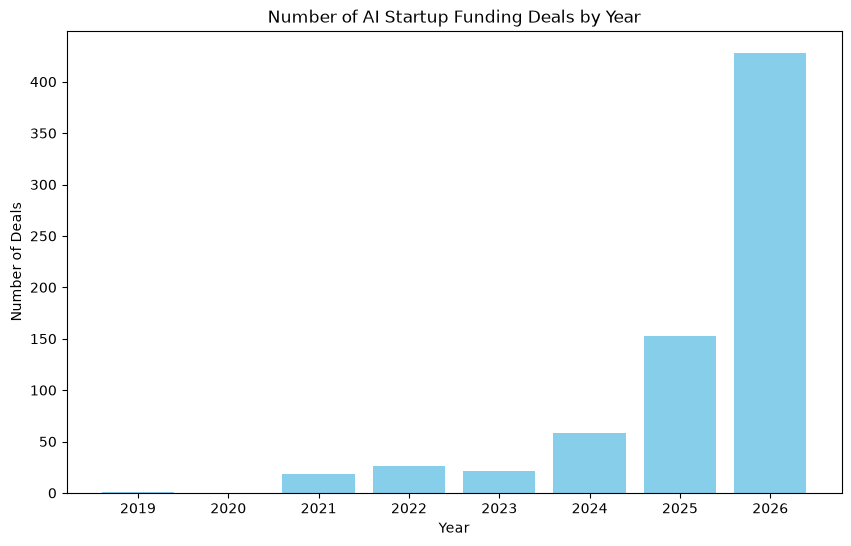

In [45]:

yearly_evolution = df.groupby('last_funding_year').agg(
    total_dollars_deployed=('Last Equity Funding Amount (in USD)', 'sum'),
    number_of_deals=('Organization Name', 'count')
)

plt.figure(figsize=(10, 6))
plt.bar(yearly_evolution.index, yearly_evolution['number_of_deals'], color='skyblue')
plt.title('Number of AI Startup Funding Deals by Year')
plt.xlabel('Year')
plt.ylabel('Number of Deals')
plt.savefig('fig1.png', dpi=300, bbox_inches='tight')
plt.show()


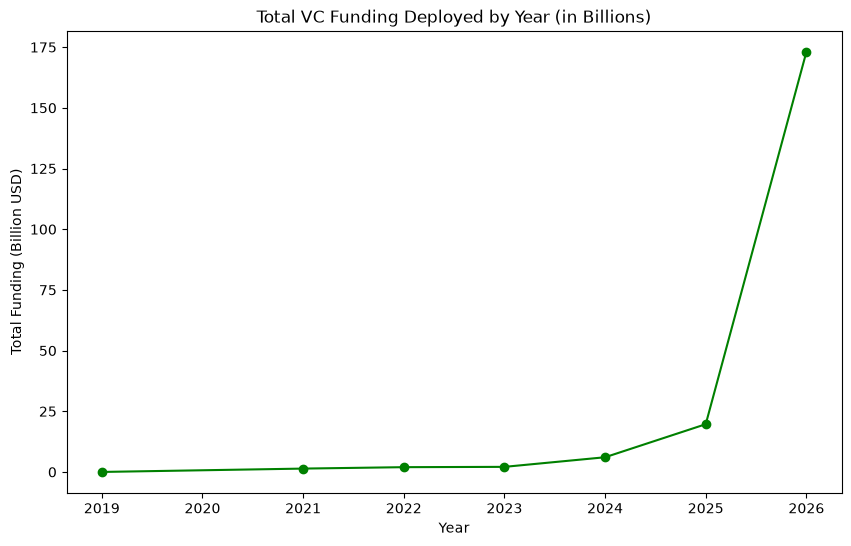

In [46]:

plt.figure(figsize=(10, 6))
plt.plot(yearly_evolution.index, yearly_evolution['total_dollars_deployed'] / 1e9, marker='o', color='green')
plt.title('Total VC Funding Deployed by Year (in Billions)')
plt.xlabel('Year')
plt.ylabel('Total Funding (Billion USD)')
plt.savefig('fig2.png', dpi=300, bbox_inches='tight')
plt.show()

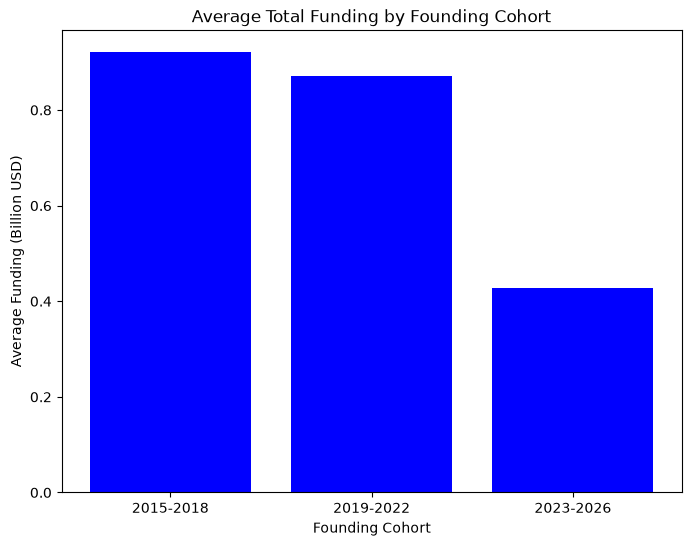

In [47]:

cohort_summary = df.groupby('funding_cohort')['Total Funding Amount (in USD)'].mean()

plt.figure(figsize=(8, 6))
plt.bar(cohort_summary.index, cohort_summary.values / 1e9, color='blue')
plt.title('Average Total Funding by Founding Cohort')
plt.xlabel('Founding Cohort')
plt.ylabel('Average Funding (Billion USD)')
plt.savefig('fig3.png', dpi=300, bbox_inches='tight')
plt.show()

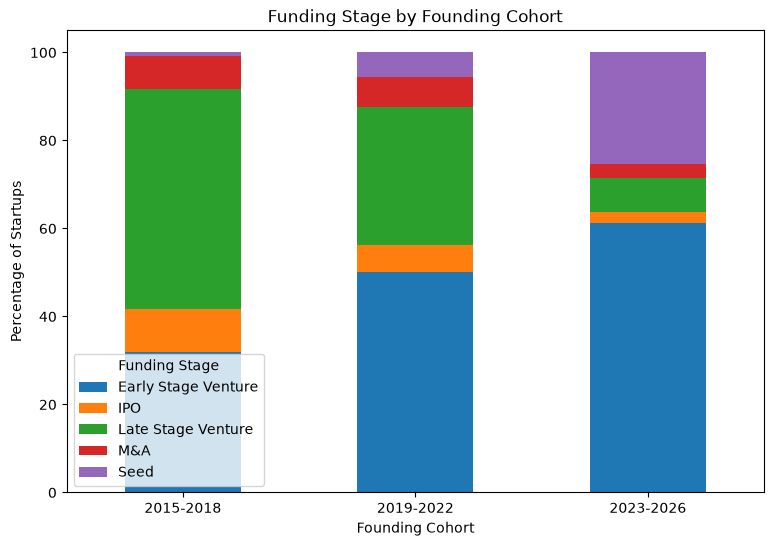

In [48]:

stage_percentages = pd.crosstab(df['funding_cohort'], df['Funding Status'], normalize='index') * 100

stage_percentages.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title('Funding Stage by Founding Cohort')
plt.xlabel('Founding Cohort')
plt.ylabel('Percentage of Startups')
plt.xticks(rotation=0)
plt.legend(title='Funding Stage')
plt.savefig('fig4.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
import statsmodels.formula.api as smf
model_raw = smf.ols(
    'employees_midpoint ~ Q("Total Funding Amount (in USD)") + founded_year',
    data=df
).fit()

print(model_raw.summary())

                            OLS Regression Results                            
Dep. Variable:     employees_midpoint   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     207.0
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           2.11e-71
Time:                        14:34:46   Log-Likelihood:                -5431.1
No. Observations:                 705   AIC:                         1.087e+04
Df Residuals:                     702   BIC:                         1.088e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [53]:
import statsmodels.formula.api as smf
model_log = smf.ols(
    'employees_midpoint ~ log_funding + founded_year',
    data=df
).fit()

print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:     employees_midpoint   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     127.5
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           5.99e-48
Time:                        14:34:53   Log-Likelihood:                -5485.3
No. Observations:                 705   AIC:                         1.098e+04
Df Residuals:                     702   BIC:                         1.099e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      9.89e+04   1.58e+04      6.275   

In [55]:
avg = df['Total Funding Amount (in USD)'].mean()
std = df['Total Funding Amount (in USD)'].std()
cutoff_value = avg + 3*std

outliers = df[df['Total Funding Amount (in USD)'] > cutoff_value]
print(outliers[['Organization Name', 'Total Funding Amount (in USD)']])

   Organization Name  Total Funding Amount (in USD)
7          CoreWeave                   4.293670e+10
31          SpaceXAI                   4.288522e+10
72         Anthropic                   1.287400e+11
75        Prometheus                   1.820000e+10


In [58]:
df_no_outliers = df[df['Total Funding Amount (in USD)'] <= cutoff_value]

model_no_outliers = smf.ols(
    'employees_midpoint ~ log_funding + founded_year',
    data=df_no_outliers
).fit()

print(model_no_outliers.summary())

                            OLS Regression Results                            
Dep. Variable:     employees_midpoint   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     115.3
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           5.38e-44
Time:                        14:36:33   Log-Likelihood:                -5382.7
No. Observations:                 701   AIC:                         1.077e+04
Df Residuals:                     698   BIC:                         1.079e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.079e+05   1.43e+04      7.528   

In [ ]:
print("Raw funding model R-squared:", round(model_raw.rsquared, 3))
print("Log funding model R-squared:", round(model_log.rsquared, 3))

Raw funding model R-squared: 0.371
Log funding model R-squared: 0.266


In [59]:
print("R-squared WITH outliers:", model_log.rsquared)
print("R-squared WITHOUT outliers:", model_no_outliers.rsquared)

R-squared WITH outliers: 0.26639338131665236
R-squared WITHOUT outliers: 0.24834439980620915


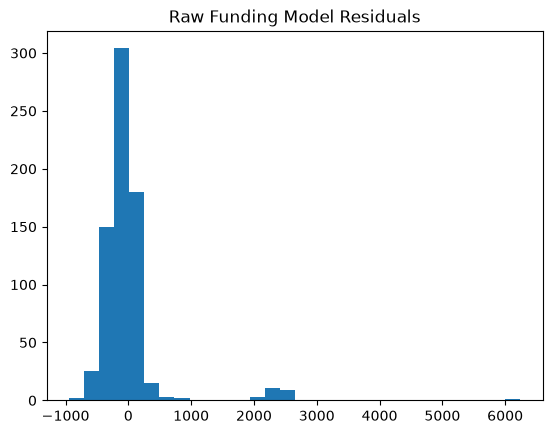

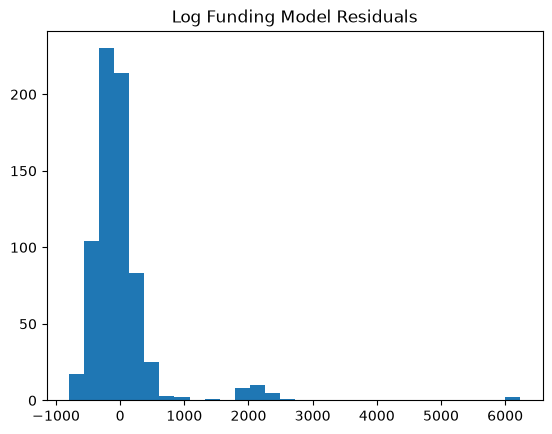

In [ ]:
import matplotlib.pyplot as plt

plt.hist(model_raw.resid, bins=30)
plt.title("Raw Funding Model Residuals")
plt.savefig('fig5.png', dpi=300, bbox_inches='tight')
plt.show()

plt.hist(model_log.resid, bins=30)
plt.title("Log Funding Model Residuals")
plt.savefig('fig6.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

rq3_columns = [
    'continuity_status',
    'Total Funding Amount (in USD)',
    'log_funding',
    'Number of Funding Rounds',
    'IPO Status'
]

print("Missing values in RQ3:")
print(df[rq3_columns].isnull().sum())

print("\nDistribution variable:")
print(df['continuity_status'].value_counts())
print("\nDistribution of IPO Status:")
print(df['IPO Status'].value_counts())

Missing values in RQ3:
continuity_status                0
Total Funding Amount (in USD)    0
log_funding                      0
Number of Funding Rounds         0
IPO Status                       0
dtype: int64

Distribution variable:
continuity_status
Early Stage        456
Late Stage         174
Successful Exit     75
Name: count, dtype: int64

Distribution of IPO Status:
IPO Status
Private    667
Public      38
Name: count, dtype: int64


In [ ]:
funding_by_stage = df.groupby('continuity_status').agg(
    average_funding=('Total Funding Amount (in USD)', 'mean'),
    median_funding=('Total Funding Amount (in USD)', 'median'),
    average_rounds=('Number of Funding Rounds', 'mean'),
    count=('Organization Name', 'count')
)
print(funding_by_stage)

                   average_funding  median_funding  average_rounds  count
continuity_status                                                        
Early Stage           1.837034e+08      59920872.0        3.388158    456
Late Stage            1.485644e+09     273750000.0        6.551724    174
Successful Exit       1.870052e+09     225000000.0        5.893333     75


In [ ]:

from scipy import stats

early = df[df['continuity_status'] == 'Early Stage']['log_funding']
late = df[df['continuity_status'] == 'Late Stage']['log_funding']
exit_group = df[df['continuity_status'] == 'Successful Exit']['log_funding']

f_stat, p_value = stats.f_oneway(early, late, exit_group)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

F-statistic: 106.520
P-value: 0.00000


In [ ]:

ipo_comparison = df.groupby('IPO Status').agg(
    average_funding=('Total Funding Amount (in USD)', 'mean'),
    median_funding=('Total Funding Amount (in USD)', 'median'),
    average_rounds=('Number of Funding Rounds', 'mean'),
    count=('Organization Name', 'count'))
print(ipo_comparison)



            average_funding  median_funding  average_rounds  count
IPO Status                                                        
Private        5.903062e+08      96000000.0        4.218891    667
Public         2.336589e+09     529142519.5        8.236842     38


In [ ]:
from scipy import stats

public = df[df['IPO Status'] == 'Public']['log_funding']
private = df[df['IPO Status'] == 'Private']['log_funding']

t_stat, p_value = stats.ttest_ind(public, private)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))

T-statistic: 4.7
P-value: 0.0


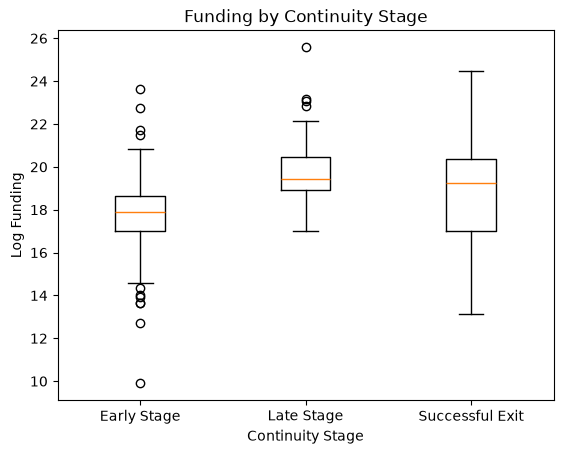

In [ ]:
import matplotlib.pyplot as plt

data = [
    df[df['continuity_status'] == 'Early Stage']['log_funding'].dropna(),
    df[df['continuity_status'] == 'Late Stage']['log_funding'].dropna(),
    df[df['continuity_status'] == 'Successful Exit']['log_funding'].dropna()
]

plt.boxplot(data, tick_labels=['Early Stage', 'Late Stage', 'Successful Exit'])

plt.title('Funding by Continuity Stage')
plt.xlabel('Continuity Stage')
plt.ylabel('Log Funding')
plt.savefig('fig7.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

print("Startups per region:")
print(df['hq_region'].value_counts())

rq4_columns = ['hq_region', 'Total Funding Amount (in USD)', 'log_funding', 'employees_midpoint', 'founded_year']
print("\nMissing values in RQ4's required columns:")
print(df[rq4_columns].isnull().sum())

Startups per region:
hq_region
North America    495
Europe           134
Asia-Pacific      76
Name: count, dtype: int64

Missing values in RQ4's required columns:
hq_region                        0
Total Funding Amount (in USD)    0
log_funding                      0
employees_midpoint               0
founded_year                     0
dtype: int64


In [ ]:
regions = ['North America', 'Europe', 'Asia-Pacific']

for region in regions:
    data = df[df['hq_region'] == region].dropna(
        subset=['employees_midpoint', 'log_funding', 'founded_year']
    )

    model = smf.ols(
        'employees_midpoint ~ log_funding + founded_year',
        data=data
    ).fit()

    print("\nRegion:", region)
    print("Number of startups:", len(data))
    print("R-squared:", round(model.rsquared, 3))
    print("Funding coefficient:", round(model.params['log_funding'], 2))
    print("Funding p-value:", round(model.pvalues['log_funding'], 5))


Region: North America
Number of startups: 495
R-squared: 0.265
Funding coefficient: 183.91
Funding p-value: 0.0

Region: Europe
Number of startups: 134
R-squared: 0.313
Funding coefficient: 139.16
Funding p-value: 0.0

Region: Asia-Pacific
Number of startups: 76
R-squared: 0.301
Funding coefficient: 122.07
Funding p-value: 0.00138


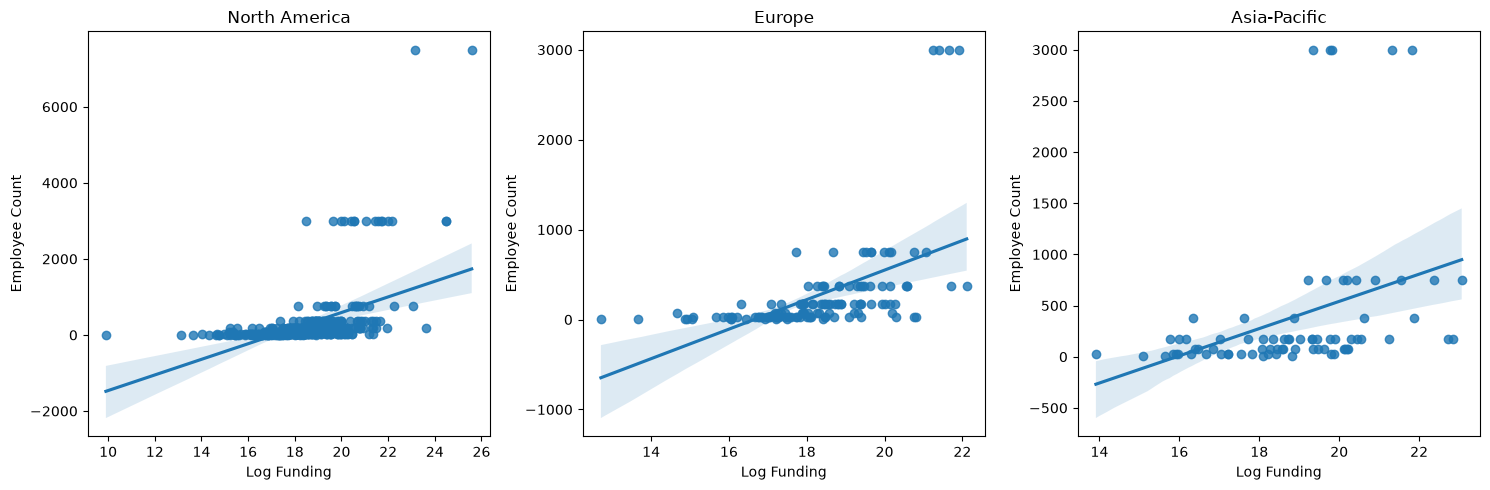

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

regions = ['North America', 'Europe', 'Asia-Pacific']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, region in enumerate(regions):

    data = df[df['hq_region'] == region]

    sns.regplot(
        x='log_funding',
        y='employees_midpoint',
        data=data,
        ax=axes[i]
    )

    axes[i].set_title(region)
    axes[i].set_xlabel('Log Funding')
    axes[i].set_ylabel('Employee Count')

plt.tight_layout()
plt.savefig('fig8.png', dpi=300, bbox_inches='tight')
plt.show()